In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
from sklearn.datasets import load_diabetes
df = load_diabetes()
x = pd.DataFrame(df['data'])
y = pd.DataFrame(df['target'])
y

,0
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0
...,...
437,178.0
438,104.0
439,132.0
440,220.0


In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=0000)

In [ ]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
x_train = s.fit_transform(x_train)
x_test = s.transform(x_test)

In [56]:
from sklearn.tree import DecisionTreeRegressor
d = DecisionTreeRegressor()
d.fit(x_train,y_train)
y_pred = d.predict(x_test)

In [57]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_pred,y_test))
print(root_mean_squared_error(y_pred,y_test))

0.00025412311759565043
75.38083490032642


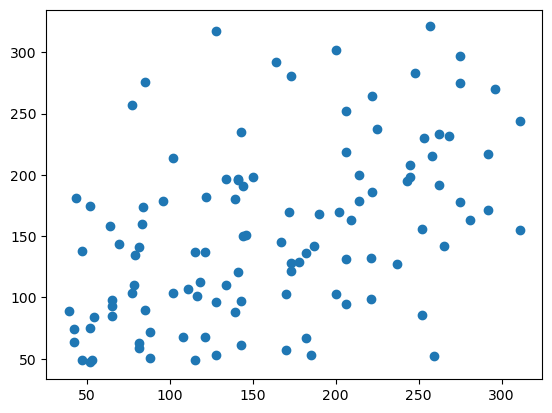

In [58]:
plt.scatter(y_pred,y_test)
plt.show()

In [59]:
params = {
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [60]:
from sklearn.model_selection import GridSearchCV
g = GridSearchCV(d,param_grid=params,cv=5,scoring="neg_mean_squared_error")
g.fit(x_train,y_train)
y_predg = g.predict(x_test)

d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "d:\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "d:\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "d:\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py", line 95, in validate

In [61]:
from sklearn.metrics import r2_score,root_mean_squared_error
print(r2_score(y_predg,y_test))
print(root_mean_squared_error(y_predg,y_test))

-1.346322759308567
67.76488117671582
